In [8]:
import pandas as pd
import numpy as np
All_Data = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/5. Final consolidation of all data/5.A. Data created in 5./5.2./Final affiliations.xlsx') 
print(All_Data.shape)

(22790, 40)


In [9]:
All_Data.rename(columns = {'Year':'year'}, inplace = True)

melted = All_Data.melt(id_vars= ['Article_ID','year'], value_vars=['0_Auth_affs_0', '0_Auth_affs_1', '0_Auth_affs_2', '0_Auth_affs_3', '0_Auth_affs_4', 
                                '1_Auth_affs_0' , '1_Auth_affs_1', '1_Auth_affs_2', '1_Auth_affs_3', '1_Auth_affs_4',
                                '2_Auth_affs_0', '2_Auth_affs_1', '2_Auth_affs_2', '2_Auth_affs_3', '2_Auth_affs_4',
                                '3_Auth_affs_0', '3_Auth_affs_1', '3_Auth_affs_2', '3_Auth_affs_3', '3_Auth_affs_4',
                                '4_Auth_affs_0', '4_Auth_affs_1', '4_Auth_affs_2' , '4_Auth_affs_3',
                                '5_Auth_affs_0',
                                '6_Auth_affs_0','7_Auth_affs_0']).dropna()

melted.rename(columns = {'variable':'Aff number'}, inplace = True)
melted.rename(columns = {'value':'Affiliation'}, inplace = True)

melted = melted.sort_values(by=['year'])

print(melted.head())
print(melted.shape)

       Article_ID  year     Aff number  \
0         2967475  1940  0_Auth_affs_0   
18582     1807581  1940  0_Auth_affs_0   
18581     1807580  1940  0_Auth_affs_0   
18580     1807579  1940  0_Auth_affs_0   
18579     1807578  1940  0_Auth_affs_0   

                                        Affiliation  
0      Cambridge Massachusetts United States (City)  
18582                                Queens College  
18581                       University Of Wisconsin  
18580                  University Of North Carolina  
18579                         Brookings Institution  
(37804, 4)


In [10]:
melted['aff_cum_counts'] = melted.groupby(['Affiliation']).cumcount()+1

melted = melted[['Article_ID' ,'Aff number', 'Affiliation','year', 'aff_cum_counts']]
melted.head()

,Article_ID,Aff number,Affiliation,year,aff_cum_counts
0,2967475,0_Auth_affs_0,Cambridge Massachusetts United States (City),1940,1
18582,1807581,0_Auth_affs_0,Queens College,1940,1
18581,1807580,0_Auth_affs_0,University Of Wisconsin,1940,1
18580,1807579,0_Auth_affs_0,University Of North Carolina,1940,1
18579,1807578,0_Auth_affs_0,Brookings Institution,1940,1


In [14]:
# Mask to remove the National Bureau Of Economic Research
mask_journal = melted['Affiliation'].isin(['National Bureau Of Economic Research', 'Centre For Economic Policy Research (Cepr, England)',' Canadian Institute For Advanced Research (Cifar)','Centre For Operations Research And Econometrics (Core, France)','National Institute Of Economic And Social Research, London','None'])
melted = melted[~mask_journal]

# Checking the top 20 occurances of Universities over the 70 years
highest_vals = melted.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals = highest_vals.sort_values(by='aff_cum_counts', ascending=False)
highest_vals.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.8. Research institutes/counts2.xlsx') 
highest_vals_10 = highest_vals.nlargest(20,'aff_cum_counts')
highest_vals_10

,Article_ID,Aff number,Affiliation,year,aff_cum_counts
9510,27805063,0_Auth_affs_0,Harvard University,2010,1858
237387,27805040,2_Auth_affs_0,University Of Chicago,2010,1483
237398,27805051,2_Auth_affs_0,Massachusetts Institute Of Technology,2010,1283
237403,27805056,2_Auth_affs_0,Stanford University,2010,1088
5499,40961016,0_Auth_affs_0,Princeton University,2010,968
237421,27804922,2_Auth_affs_0,Yale University,2010,890
237390,27805043,2_Auth_affs_0,"University Of California, Berkeley",2010,852
237294,27871241,2_Auth_affs_0,University Of Pennsylvania,2010,830
237391,27805044,2_Auth_affs_0,Northwestern University,2010,811
237394,27805047,2_Auth_affs_0,Columbia University,2010,707


(71, 5)
        Article_ID     Aff number         Affiliation  year  aff_cum_counts
18640      1814505  0_Auth_affs_0  Harvard University  1940              15
18494          356  0_Auth_affs_0  Harvard University  1941              34
18459      1807439  0_Auth_affs_0  Harvard University  1942              51
2753       1885760  0_Auth_affs_0  Harvard University  1943              57
116731     1883256  1_Auth_affs_0  Harvard University  1944              65
        Article_ID     Aff number         Affiliation  year  aff_cum_counts
124217    30034355  1_Auth_affs_0  Harvard University  2006            1648
10096     30034393  0_Auth_affs_0  Harvard University  2007            1689
119334    25098900  1_Auth_affs_0  Harvard University  2008            1750
237497    25592477  2_Auth_affs_0  Harvard University  2009            1795
9510      27805063  0_Auth_affs_0  Harvard University  2010            1858
(65, 5)


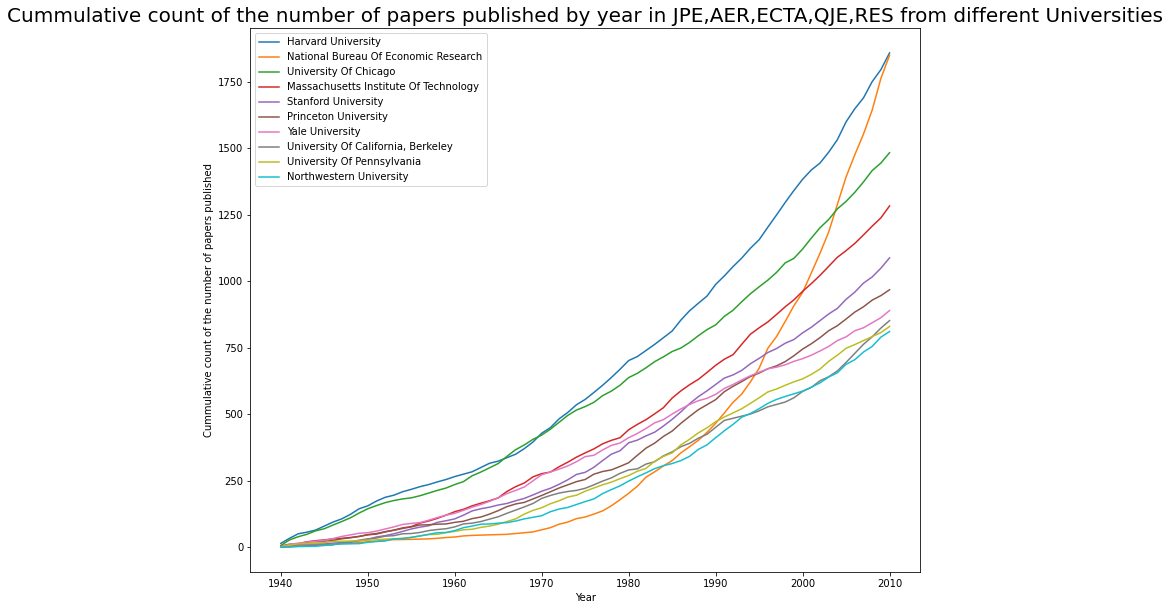

In [12]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(a.shape)
print(a.head())
print(a.tail())
b = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(b.shape)
c = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_counts'], label = highest_vals_10.iat[0,2])
plt.plot(b['year'],b['aff_cum_counts'], label = highest_vals_10.iat[1,2])
plt.plot(c['year'],c['aff_cum_counts'], label = highest_vals_10.iat[2,2])
plt.plot(d['year'],d['aff_cum_counts'], label = highest_vals_10.iat[3,2])
plt.plot(e['year'],e['aff_cum_counts'], label = highest_vals_10.iat[4,2])
plt.plot(f['year'],f['aff_cum_counts'], label = highest_vals_10.iat[5,2])
plt.plot(g['year'],g['aff_cum_counts'], label = highest_vals_10.iat[6,2])
plt.plot(h['year'],h['aff_cum_counts'], label = highest_vals_10.iat[7,2])
plt.plot(i['year'],i['aff_cum_counts'], label = highest_vals_10.iat[8,2])
plt.plot(j['year'],j['aff_cum_counts'], label = highest_vals_10.iat[9,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

plt.title('Cummulative count of the number of papers published by year in JPE,AER,ECTA,QJE,RES from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Cummulative count of the number of papers published')

plt.legend()
plt.show()

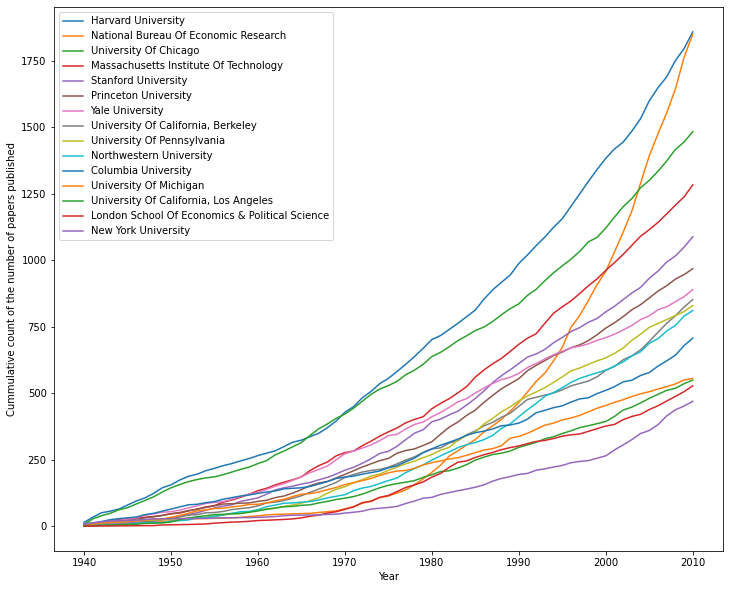

In [13]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
b = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
c = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')
l = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[11,2])].drop_duplicates(subset = ['year'], keep = 'last')
m = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[12,2])].drop_duplicates(subset = ['year'], keep = 'last')
n = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[13,2])].drop_duplicates(subset = ['year'], keep = 'last')
o = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[14,2])].drop_duplicates(subset = ['year'], keep = 'last')
p = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[15,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_counts'], label = highest_vals_10.iat[0,2])
plt.plot(b['year'],b['aff_cum_counts'], label = highest_vals_10.iat[1,2])
plt.plot(c['year'],c['aff_cum_counts'], label = highest_vals_10.iat[2,2])
plt.plot(d['year'],d['aff_cum_counts'], label = highest_vals_10.iat[3,2])
plt.plot(e['year'],e['aff_cum_counts'], label = highest_vals_10.iat[4,2])
plt.plot(f['year'],f['aff_cum_counts'], label = highest_vals_10.iat[5,2])
plt.plot(g['year'],g['aff_cum_counts'], label = highest_vals_10.iat[6,2])
plt.plot(h['year'],h['aff_cum_counts'], label = highest_vals_10.iat[7,2])
plt.plot(i['year'],i['aff_cum_counts'], label = highest_vals_10.iat[8,2])
plt.plot(j['year'],j['aff_cum_counts'], label = highest_vals_10.iat[9,2])
plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])
plt.plot(l['year'],l['aff_cum_counts'], label = highest_vals_10.iat[11,2])
plt.plot(m['year'],m['aff_cum_counts'], label = highest_vals_10.iat[12,2])
plt.plot(n['year'],n['aff_cum_counts'], label = highest_vals_10.iat[13,2])
plt.plot(o['year'],o['aff_cum_counts'], label = highest_vals_10.iat[14,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

#plt.title('Cummulative count of the number of papers published by year in JPE,AER,ECTA,QJE,RES from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Cummulative count of the number of papers published')

plt.legend()
plt.show()